# CFP_qV_Diagnostic

Analyses the conformal threshold q̂_V as a continuous miscalibration diagnostic: forecaster ranking, cross-sectional correlations, rolling q̂_V overlay.

**Output:** `fig_qV_ranking.pdf`, `fig_rolling_qv.pdf`, `fig_qv_scatter.pdf`  
**Paper:** Pele, Bolovaneanu, Ginavar, Lessmann, Härdle (2026)  
**Q** [Conformal_Oracle](https://github.com/QuantLet/Conformal_Oracle/)

> **Note:** The canonical figure for **Figure 1** (`fig_rolling_qv.pdf`) is now produced by the standalone Quantlet `CO_rolling_qV/`. This notebook is retained because it also produces `fig_qV_ranking` and `fig_qv_scatter`, and serves as a development reference.

Loaded 864 rows


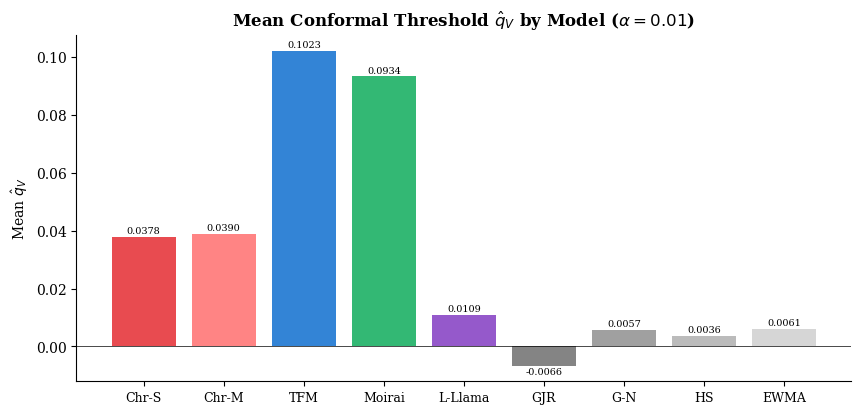

Saved fig_qV_ranking


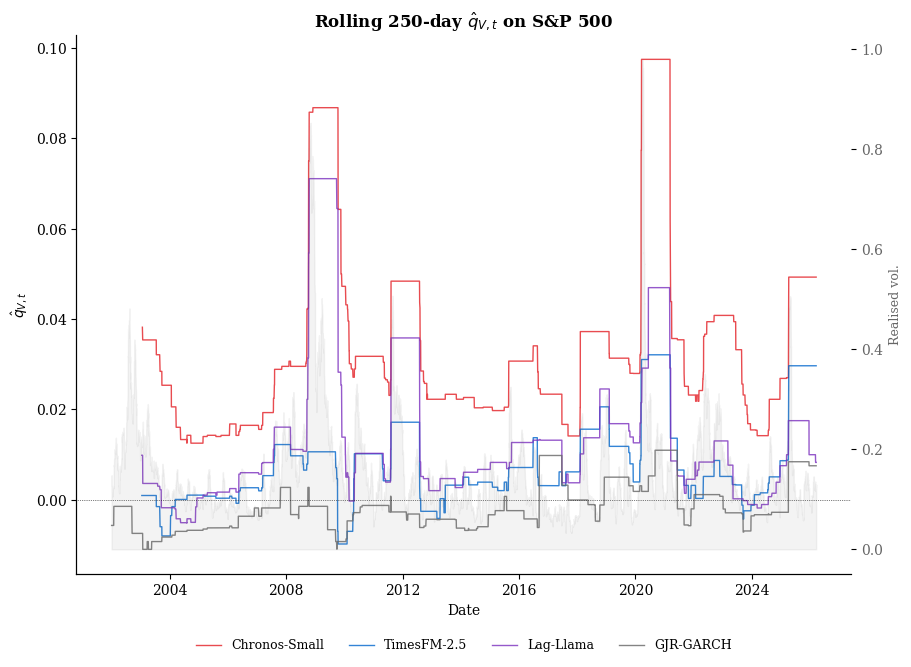

Saved fig_rolling_qv


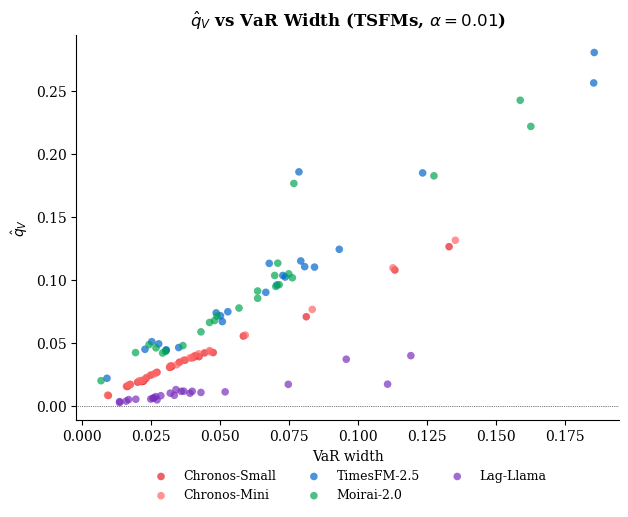

Saved fig_qv_scatter


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import shutil, warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────
DATA_DIR = Path('../cfp_ijf_data')
RES_DIR  = DATA_DIR / 'paper_outputs' / 'tables'
FIG_DIR  = DATA_DIR / 'paper_outputs' / 'figures'
ROOT_FIG = Path('../figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)
ROOT_FIG.mkdir(parents=True, exist_ok=True)

# ── Style ─────────────────────────────────────────────
C_GRAY='#666666'; C_TEAL='#00A651'; C_RED='#E31E24'
C_BLUE='#0066CC'; C_PURPLE='#7B2FBE'
plt.rcParams.update({
    'font.family':'serif', 'axes.grid':False,
    'savefig.transparent':True, 'savefig.dpi':300,
    'axes.spines.top':False, 'axes.spines.right':False,
    'font.size':10,
})

# ── Data ───────────────────────────────────────────────────────────
df  = pd.read_csv(RES_DIR / 'all_results.csv')
d01 = df[df['alpha'] == 0.01].copy()
print(f'Loaded {len(df)} rows')

MODEL_ORDER = ['Chronos-Small','Chronos-Mini','TimesFM-2.5',
               'Moirai-2.0','Lag-Llama',
               'GJR-GARCH','GARCH-N','Hist-Sim','EWMA']
MODEL_SHORT = ['Chr-S','Chr-M','TFM','Moirai','L-Llama',
               'GJR','G-N','HS','EWMA']
MODEL_COLORS = {
    'Chronos-Small':C_RED, 'Chronos-Mini':'#FF6666',
    'TimesFM-2.5':C_BLUE, 'Moirai-2.0':C_TEAL,
    'Lag-Llama':C_PURPLE,
    'GJR-GARCH':C_GRAY, 'GARCH-N':'#888888',
    'Hist-Sim':'#AAAAAA', 'EWMA':'#CCCCCC',
}

# ═══════════════════════════════════════════════════════════════════
# FIG: qV Ranking (bar chart)
# ═══════════════════════════════════════════════════════════════════
summary = d01.groupby('model')['qV'].mean().reindex(MODEL_ORDER)
fig, ax = plt.subplots(figsize=(10, 4.5))
colors = [MODEL_COLORS.get(m, C_GRAY) for m in MODEL_ORDER]
ax.bar(range(len(MODEL_ORDER)), summary.values, color=colors, alpha=0.8)
ax.set_title('Mean Conformal Threshold $\\hat{q}_V$ by Model ($\\alpha = 0.01$)',
             fontsize=12, fontweight='bold')
ax.axhline(0, color='black', lw=0.5)
ax.set_xticks(range(len(MODEL_ORDER)))
ax.set_xticklabels(MODEL_SHORT, fontsize=9)
ax.set_ylabel(r'Mean $\hat{q}_V$')
for i, v in enumerate(summary.values):
    ax.text(i, v + 0.0005*np.sign(v), f'{v:.4f}',
            ha='center', va='bottom' if v>=0 else 'top', fontsize=7)
for ext in ['pdf','png']:
    fig.savefig(FIG_DIR / f'fig_qV_ranking.{ext}', bbox_inches='tight')
for _ext in ['pdf','png']:
    shutil.copy(FIG_DIR/f'fig_qV_ranking.{_ext}', ROOT_FIG/f'fig_qV_ranking.{_ext}')
plt.show()
print('Saved fig_qV_ranking')

# ═══════════════════════════════════════════════════════════════════
# FIG: Rolling qV (S&P 500)
# ═══════════════════════════════════════════════════════════════════
rqv = pd.read_csv(RES_DIR / 'rolling_qv_SP500.csv',
                   index_col=0, parse_dates=True)
models_plot = ['Chronos-Small','TimesFM-2.5','Lag-Llama','GJR-GARCH']
colors_plot = [C_RED, C_BLUE, C_PURPLE, C_GRAY]

fig, ax = plt.subplots(figsize=(10, 7))
for m, c in zip(models_plot, colors_plot):
    if m in rqv.columns:
        s = rqv[m].dropna()
        ax.plot(s.index, s.values, color=c, lw=1, label=m, alpha=0.8)
ax.axhline(0, color='black', lw=0.5, ls=':')
ax.set_title(r'Rolling 250-day $\hat{q}_{V,t}$ on S&P 500',
             fontsize=12, fontweight='bold')
ax.set_ylabel(r'$\hat{q}_{V,t}$')
ax.set_xlabel('Date')
if 'rvol' in rqv.columns:
    ax2 = ax.twinx()
    rvol = rqv['rvol'].dropna()
    ax2.fill_between(rvol.index, 0, rvol.values, alpha=0.08, color=C_GRAY)
    ax2.set_ylabel('Realised vol.', color=C_GRAY, fontsize=9)
    ax2.tick_params(axis='y', labelcolor=C_GRAY)
    ax2.spines['top'].set_visible(False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
          ncol=4, fontsize=9, frameon=False)
for ext in ['pdf','png']:
    fig.savefig(FIG_DIR / f'fig_rolling_qv.{ext}', bbox_inches='tight')
for _ext in ['pdf','png']:
    shutil.copy(FIG_DIR/f'fig_rolling_qv.{_ext}', ROOT_FIG/f'fig_rolling_qv.{_ext}')
plt.show()
print('Saved fig_rolling_qv')

# ═══════════════════════════════════════════════════════════════════
# FIG: qV scatter (qV vs VaR width)
# ═══════════════════════════════════════════════════════════════════
tsfm = ['Chronos-Small','Chronos-Mini','TimesFM-2.5','Moirai-2.0','Lag-Llama']
fig, ax = plt.subplots(figsize=(7, 5))
for m in tsfm:
    sub = d01[d01['model']==m]
    ax.scatter(sub['VaR_width'], sub['qV'],
               color=MODEL_COLORS.get(m, C_GRAY), alpha=0.7,
               s=30, label=m, edgecolors='none')
ax.axhline(0, color='black', lw=0.5, ls=':')
ax.set_title('$\\hat{q}_V$ vs VaR Width (TSFMs, $\\alpha = 0.01$)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('VaR width')
ax.set_ylabel(r'$\hat{q}_V$')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
          ncol=3, fontsize=9, frameon=False)
for ext in ['pdf','png']:
    fig.savefig(FIG_DIR / f'fig_qv_scatter.{ext}', bbox_inches='tight')
for _ext in ['pdf','png']:
    shutil.copy(FIG_DIR/f'fig_qv_scatter.{_ext}', ROOT_FIG/f'fig_qv_scatter.{_ext}')
plt.show()
print('Saved fig_qv_scatter')